In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train_trans = pd.read_csv('../data/raw/train_transaction.csv')
train_id = pd.read_csv('../data/raw/train_identity.csv')

print("Transaction shape:", train_trans.shape)
print("Identity shape:", train_id.shape)
print("\nFraud rate:", train_trans['isFraud'].mean().round(4))

Transaction shape: (590540, 394)
Identity shape: (144233, 41)

Fraud rate: 0.035


In [2]:
# Column overview
print("=== TRANSACTION COLUMNS ===")
print(train_trans.columns.tolist())

print("\n=== IDENTITY COLUMNS ===")
print(train_id.columns.tolist())

=== TRANSACTION COLUMNS ===
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V

In [3]:
# Null rates for transaction table
null_rates = (train_trans.isnull().sum() / len(train_trans)).sort_values(ascending=False)
print("Columns with >50% nulls:", (null_rates > 0.5).sum())
print("Columns with >80% nulls:", (null_rates > 0.8).sum())
print("\nTop 20 null rates:")
print(null_rates.head(20))

Columns with >50% nulls: 174
Columns with >80% nulls: 55

Top 20 null rates:
dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
V158     0.861237
V161     0.861237
V157     0.861237
V138     0.861237
V139     0.861237
dtype: float64


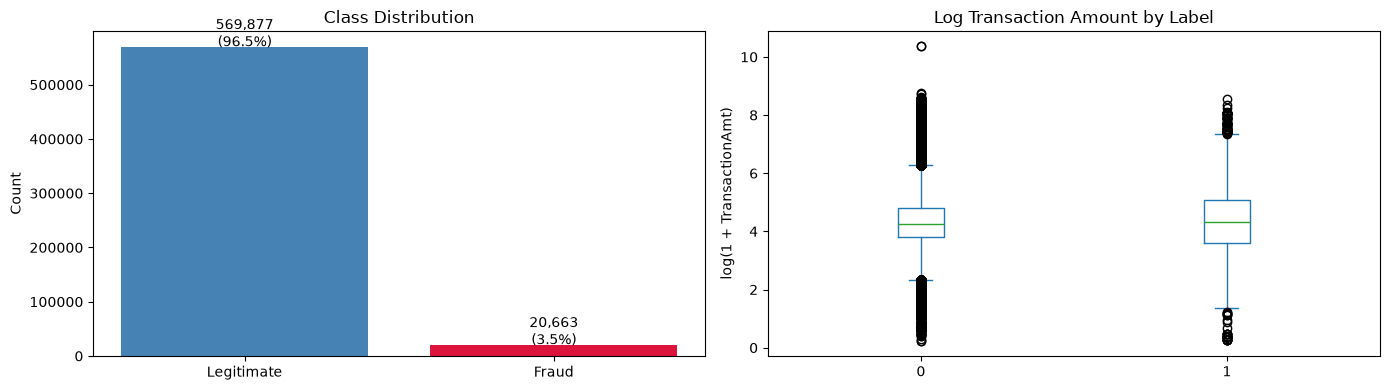

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class imbalance
class_counts = train_trans['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(train_trans)*100:.1f}%)', ha='center')

# Transaction amount by fraud label
train_trans.groupby('isFraud')['TransactionAmt'].apply(
    lambda x: np.log1p(x)
).unstack().T.plot(kind='box', ax=axes[1], label=['Legitimate', 'Fraud'])
axes[1].set_title('Log Transaction Amount by Label')
axes[1].set_ylabel('log(1 + TransactionAmt)')

plt.tight_layout()
plt.show()

# Summary stats
print(train_trans.groupby('isFraud')['TransactionAmt'].describe().round(2))